In [2]:
pwd

'/work/hpc/spine-segmentation/notebooks'

In [3]:
cd ..

/work/hpc/spine-segmentation


In [4]:
import numpy as np
import cv2
from matplotlib import pyplot as plt
import scipy
from src.utils.weight.spatial import * 

In [5]:
img = np.zeros([200, 200], dtype=float)
cv2.circle(img, [100, 100], 50, 1, -1)
kernel = np.ones([3, 3], dtype=float)

In [6]:
kernel = np.array([[1, 0, 15], [0, 1, 0]], dtype=np.float32)
pred = cv2.warpAffine(img, kernel, [200, 200])

(-0.5, 199.5, 199.5, -0.5)

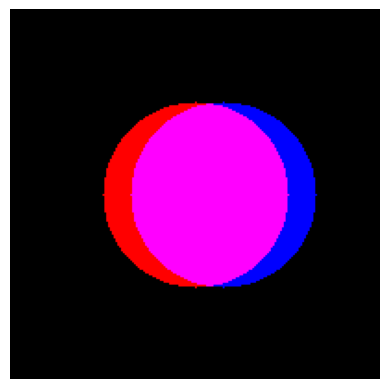

In [9]:
plt.imshow(img[:, :, None] * [1, 0, 0] + pred[:, :, None] * [0, 0, 1])
plt.axis('off')

In [114]:
# kernel = np.array([[1, 0, 15], [0, 1, 0]], dtype=np.float32)
# pred = cv2.warpAffine(img, kernel, [200, 200])

In [125]:
grad_label = cv2.GaussianBlur(np.abs(cv2.Laplacian(img, cv2.CV_64F)), (45, 45), 0, 0)
grad_pred = cv2.GaussianBlur(np.abs(cv2.Laplacian(pred, cv2.CV_64F)), (45, 45), 0, 0)
grad_label /= grad_label.max()
grad_pred /= grad_pred.max()
gradient = grad_label + grad_pred - grad_label * grad_pred
gradient = np.tanh((gradient - 0.5) * 2)
# gradient /= 5

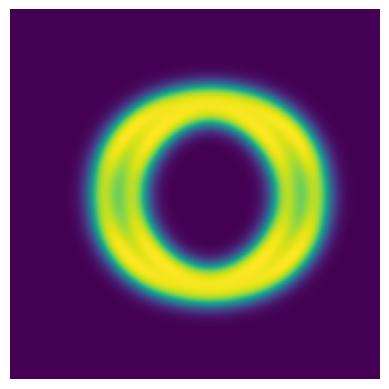

In [127]:
plt.axis('off')
plt.imshow(gradient)

In [128]:
gradient.max(), gradient.min()

(0.7615941559557649, -0.7615941559557649)

(200, 200) (200, 200)


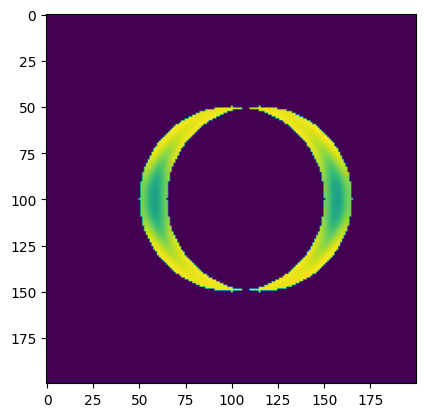

In [130]:
print(pred.shape,img.shape)
plt.imshow(gradient * (pred + img - 2 * pred * img))

2.0 0.0


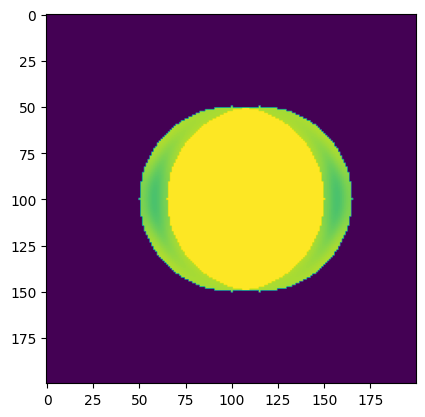

In [131]:
denominator = pred + img + gradient * (pred + img - 2 * pred * img)
print(denominator.max(), denominator.min())
plt.imshow(denominator)

In [138]:
dtm_loss = 1 - (2 * pred * img + 0.005)/(pred + img + gradient * (pred + img - 2 * pred * img) + 0.005)
loss = 1 - (2 * pred * img + 0.005) / (pred + img + 0.005)

In [139]:
diff = dtm_loss - loss
print(diff.min(), diff.max())

0.0 0.002144819532401976


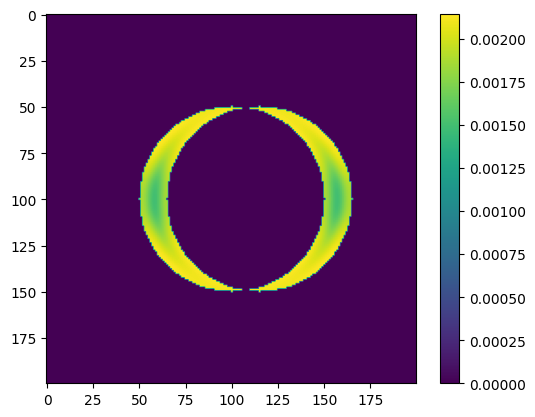

In [140]:
plt.imshow(dtm_loss - loss)
plt.colorbar()

In [122]:
shear_matrixx = np.array([
    [1, 3, 0],
    [3, 1, 0],
    [0, 0, 1],
], dtype=float)

rotated_image = cv2.warpAffine(image, shear_matrixx[0:2], (image.shape[1]*3, image.shape[0]*3))
plt.imshow(rotated_image)

NameError: name 'image' is not defined

In [ ]:
imp